# Benchmark v5 — GPU — ESOL — scaffold split, seed 1

**Task:** Predict `log(mol/L)` solubility from molecular structure.
**Size:** ~1,128 molecules
**Metric:** RMSE ↓, MAE ↓, R² ↑

**Scaffold split**, seed **1** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_1/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "esol"
TASK_TYPE = "regression"
OUT_CHANNELS = 1
BATCH_SIZE = 32
GNN_EPOCHS = 120
LSTM_EPOCHS = 120
TOX21_TABULAR = False

HPO_EPOCHS = 80  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 20
print(f"GPU HPO tier: standard — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 1

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: standard — 20 trials, 80 epochs/trial, batch=32
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold
SPLIT_SEED=1  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("esol", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "esol")
print(f"Molecules : {len(smiles)}")
print(f"Target    : [{y.min():.2f}, {y.max():.2f}]  mean={y.mean():.2f}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'esol' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/esol.csv
INFO | [esol] 1128 / 1128 valid molecules


Molecules : 1128
Target    : [-11.60, 1.58]  mean=-3.05
After bond filter: 1127 molecules


### Representations & scaffold split


In [4]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


INFO | Loaded 1128 / 1128 graphs from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/esol_conformers_n25.pkl  (n_confs=25)
INFO | Loaded splits from /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/splits/esol_scaffold_splits.pkl


3D graphs loaded: 1128 / 1127 (valid_idx mapping)
{'n_total': 1127, 'n_train': 901, 'n_val': 113, 'n_test': 113, 'n_scaffolds_total': 269, 'n_scaffolds_train': 59, 'n_scaffolds_val': 97, 'n_scaffolds_test': 113}


### GIN (2D)


In [5]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 2D — starting trial 1/20 (layers=3, hidden=192)


→ GIN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=4.7096 | val={'RMSE': 1.0821523069104115, 'MAE': 0.8518350800845476, 'R2': 0.6631903300305998}
INFO | HPO epoch   5/80 | loss=0.8887 | val={'RMSE': 1.2799937762581535, 'MAE': 1.0351938245307029, 'R2': 0.5287802456327446}
INFO | HPO epoch  10/80 | loss=0.7272 | val={'RMSE': 1.017210563311332, 'MAE': 0.829684149259619, 'R2': 0.7024023512688772}
INFO | HPO epoch  15/80 | loss=0.6279 | val={'RMSE': 1.0409421733589521, 'MAE': 0.8327005725782529, 'R2': 0.6883544134261055}
INFO | HPO epoch  20/80 | loss=0.5310 | val={'RMSE': 0.9415178734416944, 'MAE': 0.731861329316038, 'R2': 0.7450441916307242}
INFO | HPO epoch  25/80 | loss=0.4706 | val={'RMSE': 0.8609317364353308, 'MAE': 0.6877687463981915, 'R2': 0.7868206137453813}
INFO | HPO epoch  30/80 | loss=0.4513 | val={'RMSE': 0.9049627698693801, 'MAE': 0.7270175661001586, 'R2': 0.7644575445901833}
INFO | HPO epoch  35/80 | loss=0.4627 | val={'RMSE': 0.8211841418927651, 'MAE': 0.6564361704266177, 'R2': 0.8060504034114

   scaffold test: {'RMSE': 1.1228589632597474, 'MAE': 0.8574556085915692, 'R2': 0.7355596447650643}


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [6]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | DMPNN 2D — starting trial 1/20 (layers=3, hidden=192)


→ D-MPNN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=2.9703 | val={'RMSE': 1.5978109627347605, 'MAE': 1.2449098512925934, 'R2': 0.26572529791803967}
INFO | HPO epoch   5/80 | loss=0.9491 | val={'RMSE': 1.037478638745147, 'MAE': 0.7937734427705275, 'R2': 0.6904248445489156}
INFO | HPO epoch  10/80 | loss=0.5696 | val={'RMSE': 0.9097416104438606, 'MAE': 0.6725478102411844, 'R2': 0.7619633162901035}
INFO | HPO epoch  15/80 | loss=0.4641 | val={'RMSE': 0.9542995061907278, 'MAE': 0.6868676979061776, 'R2': 0.7380748683893621}
INFO | HPO epoch  20/80 | loss=0.4038 | val={'RMSE': 0.8363569154978504, 'MAE': 0.6269316983170214, 'R2': 0.7988170939635713}
INFO | HPO epoch  25/80 | loss=0.3483 | val={'RMSE': 0.7990274946784002, 'MAE': 0.6192864983515666, 'R2': 0.8163752489291914}
INFO | HPO epoch  30/80 | loss=0.3243 | val={'RMSE': 0.7272722343907384, 'MAE': 0.5898709867512231, 'R2': 0.8478745809292796}
INFO | HPO epoch  35/80 | loss=0.3231 | val={'RMSE': 0.7418912324025584, 'MAE': 0.5986311918668514, 'R2': 0.8416973263

   scaffold test: {'RMSE': 1.0809193237129537, 'MAE': 0.7839698039193069, 'R2': 0.7549448277586609}


### GIN (3D)


In [7]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 3D — starting trial 1/20 (layers=3, hidden=192)


→ GIN (3D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=3.4898 | val={'RMSE': 1.4898803676868828, 'MAE': 1.1387293891305417, 'R2': 0.4193666884647894}
INFO | HPO epoch   5/80 | loss=0.8519 | val={'RMSE': 1.0444758328644945, 'MAE': 0.77963918348593, 'R2': 0.7146381284596166}
INFO | HPO epoch  10/80 | loss=0.7711 | val={'RMSE': 1.104865939882974, 'MAE': 0.8911002462944099, 'R2': 0.6806857321297166}
INFO | HPO epoch  15/80 | loss=0.7166 | val={'RMSE': 1.215982703265279, 'MAE': 0.9964952833818651, 'R2': 0.6132289602481803}
INFO | HPO epoch  20/80 | loss=0.6160 | val={'RMSE': 0.9846152083524683, 'MAE': 0.7797089714919572, 'R2': 0.7464099365070023}
INFO | HPO epoch  25/80 | loss=0.5198 | val={'RMSE': 1.15595626408485, 'MAE': 0.9044784469678339, 'R2': 0.6504720106350572}
INFO | HPO epoch  30/80 | loss=0.5521 | val={'RMSE': 1.0067044491417714, 'MAE': 0.8113641846364579, 'R2': 0.7349040278072605}
INFO | HPO epoch  35/80 | loss=0.5214 | val={'RMSE': 1.00361357325769, 'MAE': 0.8068828754852303, 'R2': 0.7365293725296497}


   scaffold test: {'RMSE': 0.9888925520099546, 'MAE': 0.7579952233133063, 'R2': 0.7996122284986277}


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [8]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | SchNet — starting trial 1/20


→ SchNet (3D coords) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=6.1658 | val={'RMSE': 1.1203188738355778, 'MAE': 0.9037516221272207, 'R2': 0.6716912494678322}
INFO | HPO epoch   5/80 | loss=0.9618 | val={'RMSE': 1.1287910051028571, 'MAE': 0.8737267109408843, 'R2': 0.666706968653217}
INFO | HPO epoch  10/80 | loss=0.9246 | val={'RMSE': 1.2384430075993722, 'MAE': 0.9712114083555947, 'R2': 0.5988089794689728}
INFO | HPO epoch  15/80 | loss=0.6459 | val={'RMSE': 0.9717637223511989, 'MAE': 0.7552754377896806, 'R2': 0.7529865978316013}
INFO | HPO epoch  20/80 | loss=0.5744 | val={'RMSE': 0.9475257413801575, 'MAE': 0.7244303594384573, 'R2': 0.7651550705454839}
INFO | HPO epoch  25/80 | loss=0.5130 | val={'RMSE': 0.8422761639489356, 'MAE': 0.653000196920032, 'R2': 0.8144298262916106}
INFO | HPO epoch  30/80 | loss=0.4299 | val={'RMSE': 0.9824161945905735, 'MAE': 0.7738597478750533, 'R2': 0.7475413943933492}
INFO | HPO epoch  35/80 | loss=0.3484 | val={'RMSE': 0.8334528942875741, 'MAE': 0.643844697064003, 'R2': 0.8182973457417

   scaffold test: {'RMSE': 1.0442596038038836, 'MAE': 0.7876262069407818, 'R2': 0.7765450602344488}


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [9]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/20


→ SMILES LSTM (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=6.2207 | val={'RMSE': 1.6751092163854417, 'MAE': 1.292740483858944, 'R2': 0.1929619172533713}
INFO | HPO epoch   5/80 | loss=0.8403 | val={'RMSE': 1.1726536834571313, 'MAE': 0.9411223941540297, 'R2': 0.6044992451251152}
INFO | HPO epoch  10/80 | loss=0.5335 | val={'RMSE': 1.0700167716169544, 'MAE': 0.8827221365233439, 'R2': 0.6707021141380616}
INFO | HPO epoch  15/80 | loss=0.4234 | val={'RMSE': 1.010098681123295, 'MAE': 0.8291426822543144, 'R2': 0.7065491439854017}
INFO | HPO epoch  20/80 | loss=0.3451 | val={'RMSE': 1.002937967501215, 'MAE': 0.8153974933434377, 'R2': 0.7106950147446124}
INFO | HPO epoch  25/80 | loss=0.2671 | val={'RMSE': 1.0249302089428747, 'MAE': 0.8331400516022623, 'R2': 0.697868254200348}
INFO | HPO epoch  30/80 | loss=0.2525 | val={'RMSE': 1.0463318361279148, 'MAE': 0.8323157086836553, 'R2': 0.6851188581014596}
INFO | Early stop at epoch 34 (patience=15)
INFO | LSTM HPO — trial 1/20 finished | val=0.950646 | best=0.950646
INFO | LS

   scaffold test: {'RMSE': 1.0755064823575748, 'MAE': 0.879598304068884, 'R2': 0.7573929727237116}


### Finalize GPU + merge


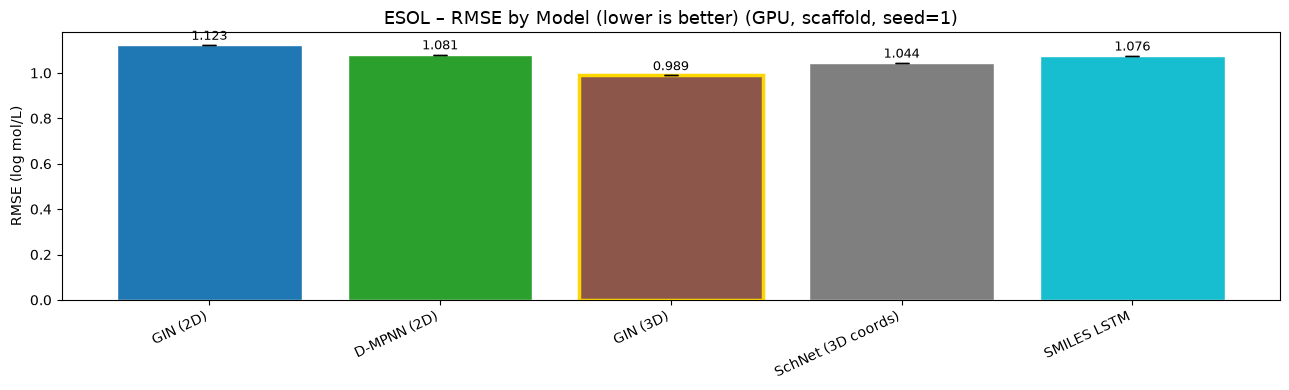

=== ESOL Results (5/12 models) ===
                               RMSE              MAE               R2
Model                                                                
GIN (2D)            1.1229 ± 0.0000  0.8575 ± 0.0000  0.7356 ± 0.0000
D-MPNN (2D)         1.0809 ± 0.0000  0.7840 ± 0.0000  0.7549 ± 0.0000
GIN (3D)            0.9889 ± 0.0000  0.7580 ± 0.0000  0.7996 ± 0.0000
SchNet (3D coords)  1.0443 ± 0.0000  0.7876 ± 0.0000  0.7765 ± 0.0000
SMILES LSTM         1.0755 ± 0.0000  0.8796 ± 0.0000  0.7574 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/esol_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_1/scaffold/gpu/esol_rmse_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results

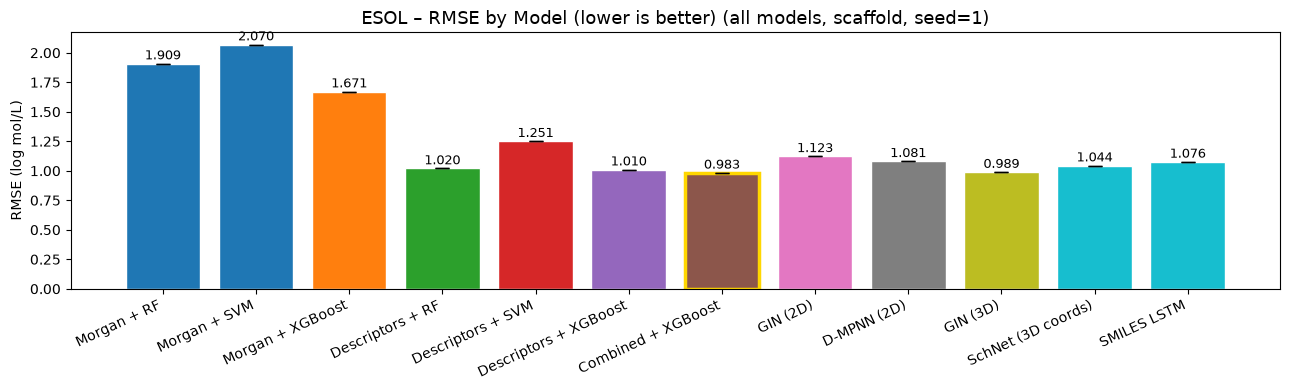

=== ESOL Results (12/12 models) ===
                                  RMSE              MAE               R2
Model                                                                   
Morgan + RF            1.9087 ± 0.0000  1.4915 ± 0.0000  0.2359 ± 0.0000
Morgan + SVM           2.0696 ± 0.0000  1.5921 ± 0.0000  0.1016 ± 0.0000
Morgan + XGBoost       1.6711 ± 0.0000  1.3139 ± 0.0000  0.4143 ± 0.0000
Descriptors + RF       1.0196 ± 0.0000  0.7818 ± 0.0000  0.7820 ± 0.0000
Descriptors + SVM      1.2510 ± 0.0000  0.9144 ± 0.0000  0.6718 ± 0.0000
Descriptors + XGBoost  1.0099 ± 0.0000  0.7567 ± 0.0000  0.7861 ± 0.0000
Combined + XGBoost     0.9827 ± 0.0000  0.7444 ± 0.0000  0.7975 ± 0.0000
GIN (2D)               1.1229 ± 0.0000  0.8575 ± 0.0000  0.7356 ± 0.0000
D-MPNN (2D)            1.0809 ± 0.0000  0.7840 ± 0.0000  0.7549 ± 0.0000
GIN (3D)               0.9889 ± 0.0000  0.7580 ± 0.0000  0.7996 ± 0.0000
SchNet (3D coords)     1.0443 ± 0.0000  0.7876 ± 0.0000  0.7765 ± 0.0000
SMILES LSTM    

In [10]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"ESOL – RMSE by Model (lower is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (log mol/L)", minimize=True)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"ESOL – RMSE by Model (lower is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="RMSE (log mol/L)", minimize=True)
else:
    print("Run CPU notebook first for combined results.")
